# ApacheJIT Data Preprocessing

Just-In-Time Defect Prediction — Data Preparation Pipeline

This notebook prepares the ApacheJIT dataset for training four deep
learning architectures (MLP, Wide & Deep, TabNet, TabTransformer) on
13 structured commit-level metrics. All downstream models consume the
identical artifacts produced here to ensure a controlled comparison.

## 1. Environment Setup

In [26]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [27]:
import os

import joblib
import numpy as np
import pandas as pd
import torch
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight

## 2. Configuration

In [28]:
DATA_PATH = "/content/drive/MyDrive/dataset/apachejit_total.csv"
OUTPUT_DIR = "/content/drive/MyDrive/DL-Assignment/data/processed"

FEATURE_COLUMNS = [
    "la", "ld", "nf", "nd", "ns", "ent",
    "ndev", "age", "nuc", "aexp", "arexp", "asexp",
]
LABEL_COLUMN = "buggy"

TRAIN_YEAR_MAX = 2014
VAL_YEAR_MIN = 2015
VAL_YEAR_MAX = 2016
TEST_YEAR_MIN = 2017

RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

## 3. Data Loading

In [29]:
df = pd.read_csv(DATA_PATH)

print(f"Loaded dataset: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Year range: {df["year"].min()}-{df["year"].max()}")

Loaded dataset: 106674 rows, 18 columns
Year range: 2003-2019


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 106674 entries, 0 to 106673
Data columns (total 18 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   commit_id    106674 non-null  object 
 1   project      106674 non-null  object 
 2   buggy        106674 non-null  bool   
 3   fix          106674 non-null  bool   
 4   year         106674 non-null  int64  
 5   author_date  106674 non-null  int64  
 6   la           106674 non-null  int64  
 7   ld           106674 non-null  int64  
 8   nf           106674 non-null  int64  
 9   nd           106674 non-null  int64  
 10  ns           106674 non-null  int64  
 11  ent          106674 non-null  float64
 12  ndev         106674 non-null  float64
 13  age          106674 non-null  float64
 14  nuc          106674 non-null  float64
 15  aexp         106674 non-null  int64  
 16  arexp        106674 non-null  float64
 17  asexp        106674 non-null  float64
dtypes: bool(2), float64(6), 

In [31]:
df.head()

,commit_id,project,buggy,fix,year,author_date,la,ld,nf,nd,ns,ent,ndev,age,nuc,aexp,arexp,asexp
0,7b8480744ea6e6fb41efd4329bb470c8f3c763db,apache/groovy,False,False,2003,1070355653,372,23,8,3,3,2.669743,0.250000,3.625000,2.125,243,243.0,0.683585
1,192b631e7be302ecde822546ba70a9853ddbda01,apache/groovy,False,False,2003,1063298262,2,2,2,2,1,1.000000,1.000000,0.000000,2.500,19,19.0,14.000000
2,0ab6465a7dece117c61c3efd3ec95d20524bdad6,apache/groovy,False,False,2003,1069704572,41,26,3,3,2,1.237612,0.666667,5.333333,45.000,233,233.0,0.000606
3,449241d5fa1aeadd5eb9fa1280d4104dc0dfb891,apache/groovy,False,False,2003,1068487625,8,6,2,1,1,0.591673,1.000000,3.000000,35.500,64,64.0,55.000000
4,698df9f5b0816e05bbf97a390428f8ef94e0cdbf,apache/groovy,False,False,2003,1063313516,70,4,6,3,1,2.519672,0.333333,0.000000,6.000,27,27.0,22.000000


## 4. Exploratory Data Analysis

### 4.1 Missing Values

In [32]:
missing_summary = df.isnull().sum()
missing_summary = missing_summary[missing_summary > 0]

if missing_summary.empty:
    print(f"No missing values detected across {df.shape[1]} columns.")
else:
    print(f"Missing values detected:\n{missing_summary}")

No missing values detected across 18 columns.


### 4.2 Class Distribution

In [25]:
class_distribution = df[LABEL_COLUMN].value_counts(normalize=True)
print(f"Class distribution:\n{class_distribution}")

Class distribution:
buggy
False    0.735278
True     0.264722
Name: proportion, dtype: float64


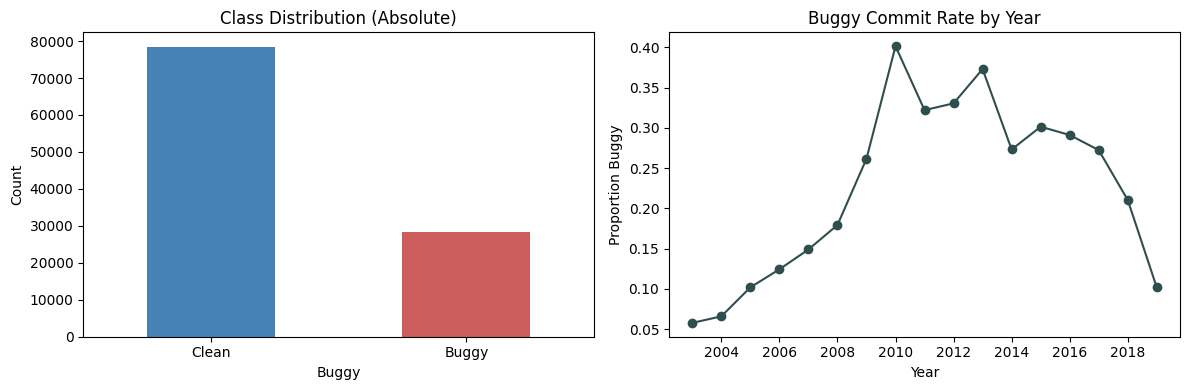

In [33]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df[LABEL_COLUMN].value_counts().plot(kind="bar", ax=axes[0], color=["steelblue", "indianred"])
axes[0].set_title("Class Distribution (Absolute)")
axes[0].set_xlabel("Buggy")
axes[0].set_ylabel("Count")
axes[0].set_xticklabels(["Clean", "Buggy"], rotation=0)

df.groupby("year")[LABEL_COLUMN].mean().plot(ax=axes[1], marker="o", color="darkslategray")
axes[1].set_title("Buggy Commit Rate by Year")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Proportion Buggy")

plt.tight_layout()
plt.show()

### 4.3 Feature Distributions

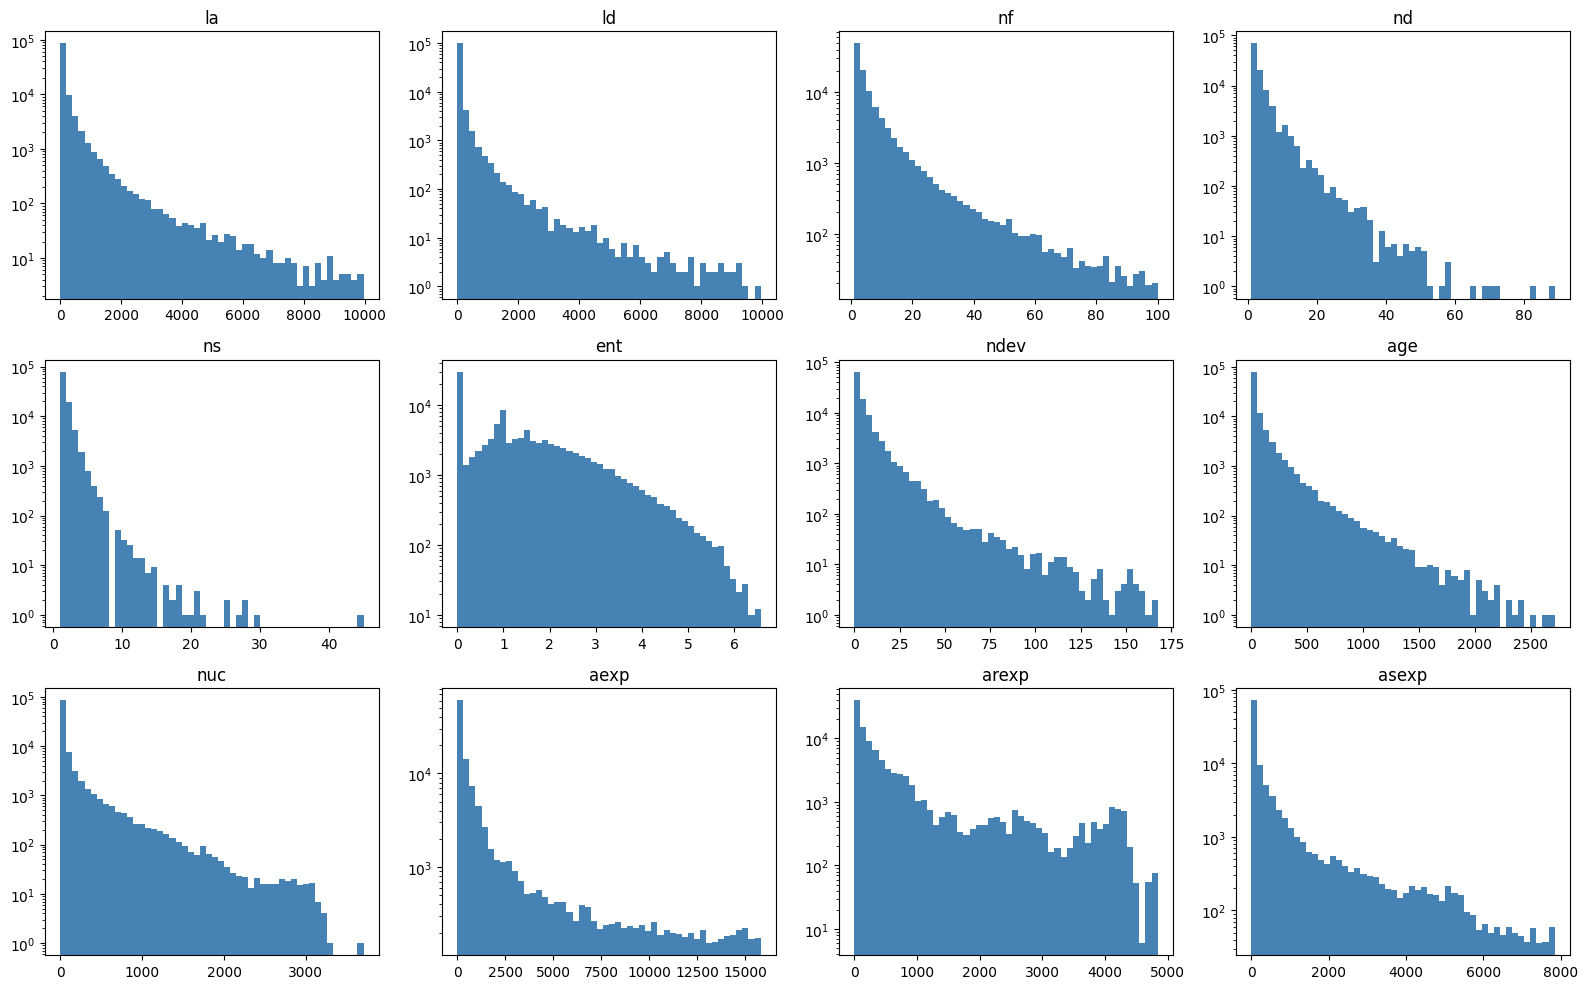

In [34]:
fig, axes = plt.subplots(3, 4, figsize=(16, 10))

for ax, col in zip(axes.flatten(), FEATURE_COLUMNS):
    ax.hist(df[col], bins=50, color="steelblue")
    ax.set_title(col)
    ax.set_yscale("log")

plt.tight_layout()
plt.show()

### 4.4 Feature Correlation

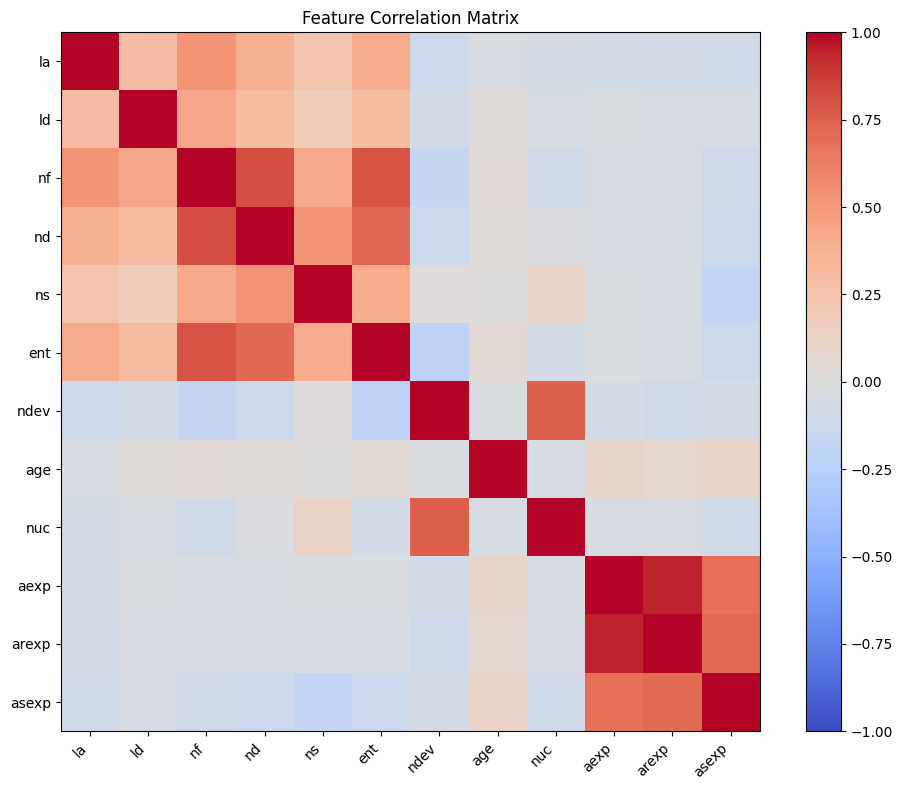

In [35]:
correlation_matrix = df[FEATURE_COLUMNS].corr()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(correlation_matrix, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(FEATURE_COLUMNS)))
ax.set_yticks(range(len(FEATURE_COLUMNS)))
ax.set_xticklabels(FEATURE_COLUMNS, rotation=45, ha="right")
ax.set_yticklabels(FEATURE_COLUMNS)
fig.colorbar(im, ax=ax)
ax.set_title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

## 5. Chronological Train / Validation / Test Split

The dataset spans 2003-2019. A chronological split is used instead of
a random split or k-fold cross-validation: k-fold would shuffle
commits across time, allowing a fold to validate on earlier years
than it trains on, which reintroduces temporal leakage. Splitting by
year mirrors real deployment, where a model is trained on historical
commits and evaluated on future ones.

| Split      | Years       |
|------------|-------------|
| Train      | 2003-2014   |
| Validation | 2015-2016   |
| Test       | 2017-2019   |

In [36]:
def chronological_split(
    frame: pd.DataFrame,
    train_year_max: int,
    val_year_min: int,
    val_year_max: int,
    test_year_min: int,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """Split a dataframe into train/val/test partitions by commit year."""
    train = frame[frame["year"] <= train_year_max].reset_index(drop=True)
    val = frame[
        (frame["year"] >= val_year_min) & (frame["year"] <= val_year_max)
    ].reset_index(drop=True)
    test = frame[frame["year"] >= test_year_min].reset_index(drop=True)
    return train, val, test

In [37]:
train_df, val_df, test_df = chronological_split(
    df, TRAIN_YEAR_MAX, VAL_YEAR_MIN, VAL_YEAR_MAX, TEST_YEAR_MIN
)

for name, split_df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    print(
        f"{name:<5} | rows={len(split_df):<7} | years={split_df["year"].min()}-{split_df["year"].max()} | buggy_ratio={split_df[LABEL_COLUMN].mean():.4f}"
    )

train | rows=52133   | years=2003-2014 | buggy_ratio=0.2909
val   | rows=24430   | years=2015-2016 | buggy_ratio=0.2970
test  | rows=30111   | years=2017-2019 | buggy_ratio=0.1932


## 6. Feature and Label Extraction

In [38]:
def extract_features_labels(
    frame: pd.DataFrame, feature_cols: list[str], label_col: str
) -> tuple[np.ndarray, np.ndarray]:
    """Extract feature matrix and integer-encoded label vector."""
    X = frame[feature_cols].values.astype(np.float32)
    y = frame[label_col].astype(int).values
    return X, y

In [39]:
X_train, y_train = extract_features_labels(train_df, FEATURE_COLUMNS, LABEL_COLUMN)
X_val, y_val = extract_features_labels(val_df, FEATURE_COLUMNS, LABEL_COLUMN)
X_test, y_test = extract_features_labels(test_df, FEATURE_COLUMNS, LABEL_COLUMN)

print(f"X_train={X_train.shape}  X_val={X_val.shape}  X_test={X_test.shape}")

X_train=(52133, 12)  X_val=(24430, 12)  X_test=(30111, 12)


## 7. Feature Scaling

The scaler is fit exclusively on the training partition. Fitting on
validation or test data would leak their distribution statistics
into training, which the assignment's data-leakage criterion
explicitly penalizes.

In [40]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f"Post-scaling train mean={np.round(X_train_scaled.mean(axis=0), 3)}")
print(f"Post-scaling train std={np.round(X_train_scaled.std(axis=0), 3)}")

Post-scaling train mean=[-0.  0. -0.  0. -0.  0.  0. -0. -0.  0.  0.  0.]
Post-scaling train std=[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


## 8. Class Imbalance Handling

The training set is imbalanced (~74% clean, ~26% buggy). Rather than
resampling or synthesizing rows, class weights are computed and
applied directly in each model's loss function. This keeps the
original data distribution intact and is applied identically across
all four architectures to preserve a fair comparison.

In [41]:
class_weights = compute_class_weight(
    class_weight="balanced", classes=np.array([0, 1]), y=y_train
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32)

print(f"Class weights [clean, buggy] = {np.round(class_weights, 4)}")

Class weights [clean, buggy] = [0.7051 1.7187]


## 9. Persist Processed Artifacts

All four models load these artifacts directly rather than repeating
preprocessing, guaranteeing identical inputs across the comparison.

In [42]:
def save_artifacts(output_dir: str, arrays: dict[str, np.ndarray], scaler_obj: StandardScaler) -> None:
    """Persist processed arrays and the fitted scaler to disk."""
    os.makedirs(output_dir, exist_ok=True)
    for name, array in arrays.items():
        np.save(os.path.join(output_dir, f"{name}.npy"), array)
    joblib.dump(scaler_obj, os.path.join(output_dir, "scaler.pkl"))

In [43]:
artifacts = {
    "X_train": X_train_scaled,
    "y_train": y_train,
    "X_val": X_val_scaled,
    "y_val": y_val,
    "X_test": X_test_scaled,
    "y_test": y_test,
    "class_weights": class_weights,
}

save_artifacts(OUTPUT_DIR, artifacts, scaler)
print(f"Artifacts saved to {OUTPUT_DIR}")

Artifacts saved to /content/drive/MyDrive/DL-Assignment/data/processed


## 10. Integrity Check

In [44]:
def verify_artifacts(output_dir: str, expected: dict[str, np.ndarray]) -> None:
    """Reload saved artifacts and confirm shapes match the in-memory versions."""
    for name, array in expected.items():
        reloaded = np.load(os.path.join(output_dir, f"{name}.npy"))
        assert reloaded.shape == array.shape, f"Shape mismatch for {name}"
    print(f"Integrity check passed: {len(expected)} artifacts verified.")

In [45]:
verify_artifacts(OUTPUT_DIR, artifacts)

Integrity check passed: 7 artifacts verified.


## Summary

| Artifact | Shape | Description |
|---|---|---|
| `X_train.npy` / `y_train.npy` | commits from 2003-2014 | Scaled features / labels |
| `X_val.npy` / `y_val.npy` | commits from 2015-2016 | Scaled features / labels |
| `X_test.npy` / `y_test.npy` | commits from 2017-2019 | Scaled features / labels |
| `class_weights.npy` | shape (2,) | Balanced weights for [clean, buggy] |
| `scaler.pkl` | — | Fitted `StandardScaler`, reused for any future inference |